# **PROYECTO: INTRODUCCIÓN AL ANÁLISIS ESTADÍSTICO**

Una vez visto el ***Módulo 2: Fundamentos Estadísticos***, se presenta la siguiente actividad para que el alumnado pueda poner a prueba lo aprendido durante este módulo.

Dentro de la siguiente dinámica, realizar el siguiente **análisis exploratorio con aprendizaje estadístico** de cualquier dataset proveniente de la librería de ***Seaborn*** que no haya sido utilizado.

Se sugiere los siguientes puntos para llevar a cabo lo anterior:

*   Realizar un **análisis descriptivo** para comprender comportamiento de la descripción de los datos a través de resúmenes.
*   Realizar un **aprendizaje estadístico** para predecir comportamientos lineales de datos a través de la regresión lineal simple.

## **1. SELECCIÓN Y CARGA DEL DATASET**

Para este proyecto se utiliza el dataset **`penguins`**.

Este conjunto contiene mediciones de **344 pingüinos** de tres especies del archipiélago Palmer (Antártida). Incluye variables **numéricas** (largo y profundidad del pico, largo de la aleta y masa corporal) y **categóricas** (especie, isla y sexo).

In [4]:
# Importar librerías
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [5]:
# Cargar el dataset 'penguins' de Seaborn
df = sns.load_dataset('penguins')
df.head()

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female


## **2. ANÁLISIS DESCRIPTIVO**

In [6]:
# Información general: tipos de dato y valores no nulos
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 344 entries, 0 to 343
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   species            344 non-null    object 
 1   island             344 non-null    object 
 2   bill_length_mm     342 non-null    float64
 3   bill_depth_mm      342 non-null    float64
 4   flipper_length_mm  342 non-null    float64
 5   body_mass_g        342 non-null    float64
 6   sex                333 non-null    object 
dtypes: float64(4), object(3)
memory usage: 18.9+ KB


In [7]:
# Dimensiones del dataset
print(f'El dataset cuenta con {df.shape[0]} registros y {df.shape[1]} variables.')

El dataset cuenta con 344 registros y 7 variables.


### **Resumen estadístico de las variables numéricas**

In [8]:
# Medidas de tendencia central y dispersión
df.describe()

,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g
count,342.000000,342.000000,342.000000,342.000000
mean,43.921930,17.151170,200.915205,4201.754386
std,5.459584,1.974793,14.061714,801.954536
min,32.100000,13.100000,172.000000,2700.000000
25%,39.225000,15.600000,190.000000,3550.000000
50%,44.450000,17.300000,197.000000,4050.000000
75%,48.500000,18.700000,213.000000,4750.000000
max,59.600000,21.500000,231.000000,6300.000000


### **Exploración de las variables categóricas**

In [9]:
categoricas = ['species', 'island', 'sex']

for col in categoricas:
    print(f'\n--- {col} ---')
    print(df[col].value_counts())


--- species ---
species
Adelie       152
Gentoo       124
Chinstrap     68
Name: count, dtype: int64

--- island ---
island
Biscoe       168
Dream        124
Torgersen     52
Name: count, dtype: int64

--- sex ---
sex
Male      168
Female    165
Name: count, dtype: int64


### **Tratamiento de valores nulos**

El dataset presenta algunos valores faltantes. Dado que representan una proporción muy pequeña del total, se opta por **eliminarlos** para no introducir sesgos por imputación.

In [10]:
# Verificar valores nulos por columna
print(df.isnull().sum())

species               0
island                0
bill_length_mm        2
bill_depth_mm         2
flipper_length_mm     2
body_mass_g           2
sex                  11
dtype: int64


In [11]:
# Eliminar registros con valores faltantes
df = df.dropna().reset_index(drop=True)
print(f'Registros tras eliminar nulos: {len(df)}')

Registros tras eliminar nulos: 333


### **Distribución de las variables numéricas**

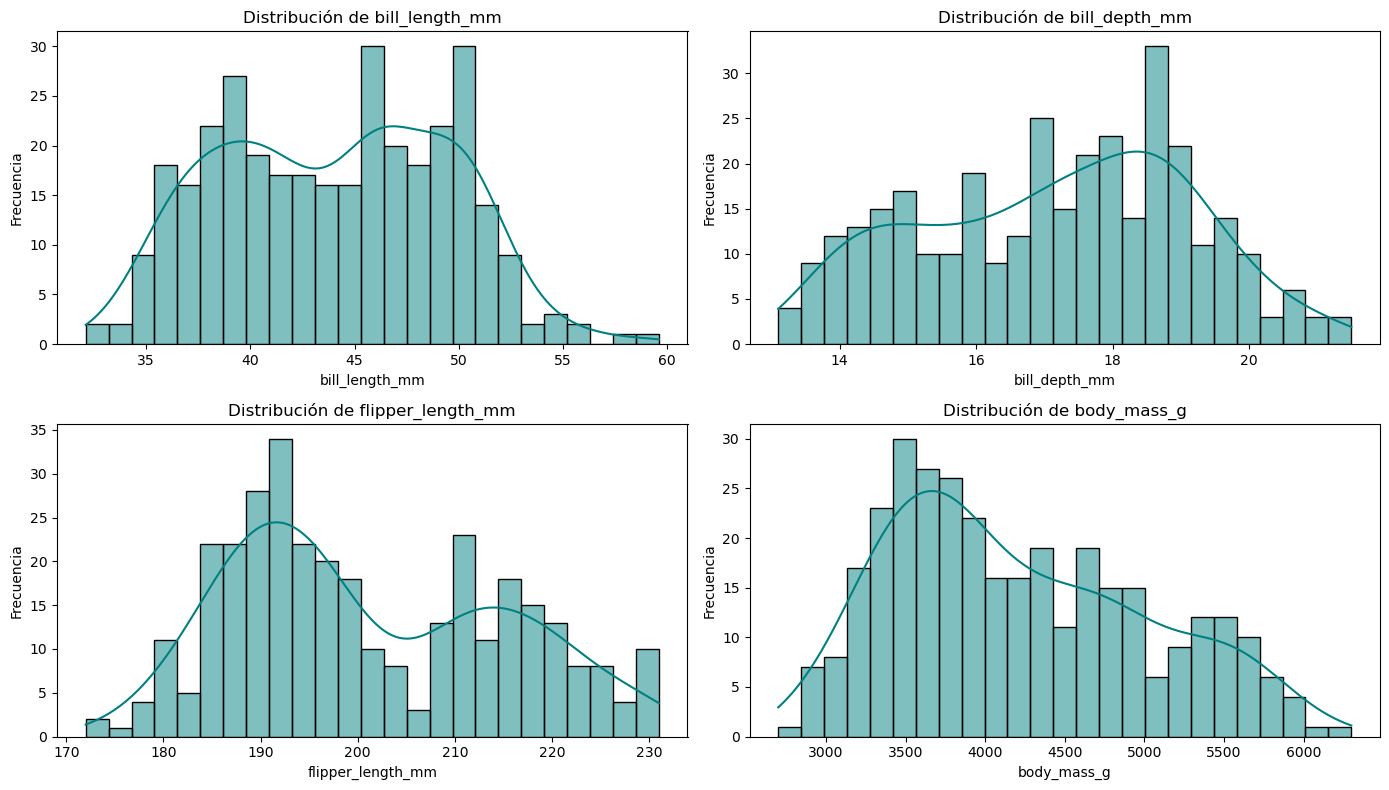

In [12]:
numericas = ['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g']

plt.figure(figsize=(14, 8))
for i, col in enumerate(numericas, 1):
    plt.subplot(2, 2, i)
    sns.histplot(df[col], kde=True, color='teal', bins=25)
    plt.title(f'Distribución de {col}')
    plt.xlabel(col)
    plt.ylabel('Frecuencia')
plt.tight_layout()
plt.show()

### **Diagramas de caja por especie**

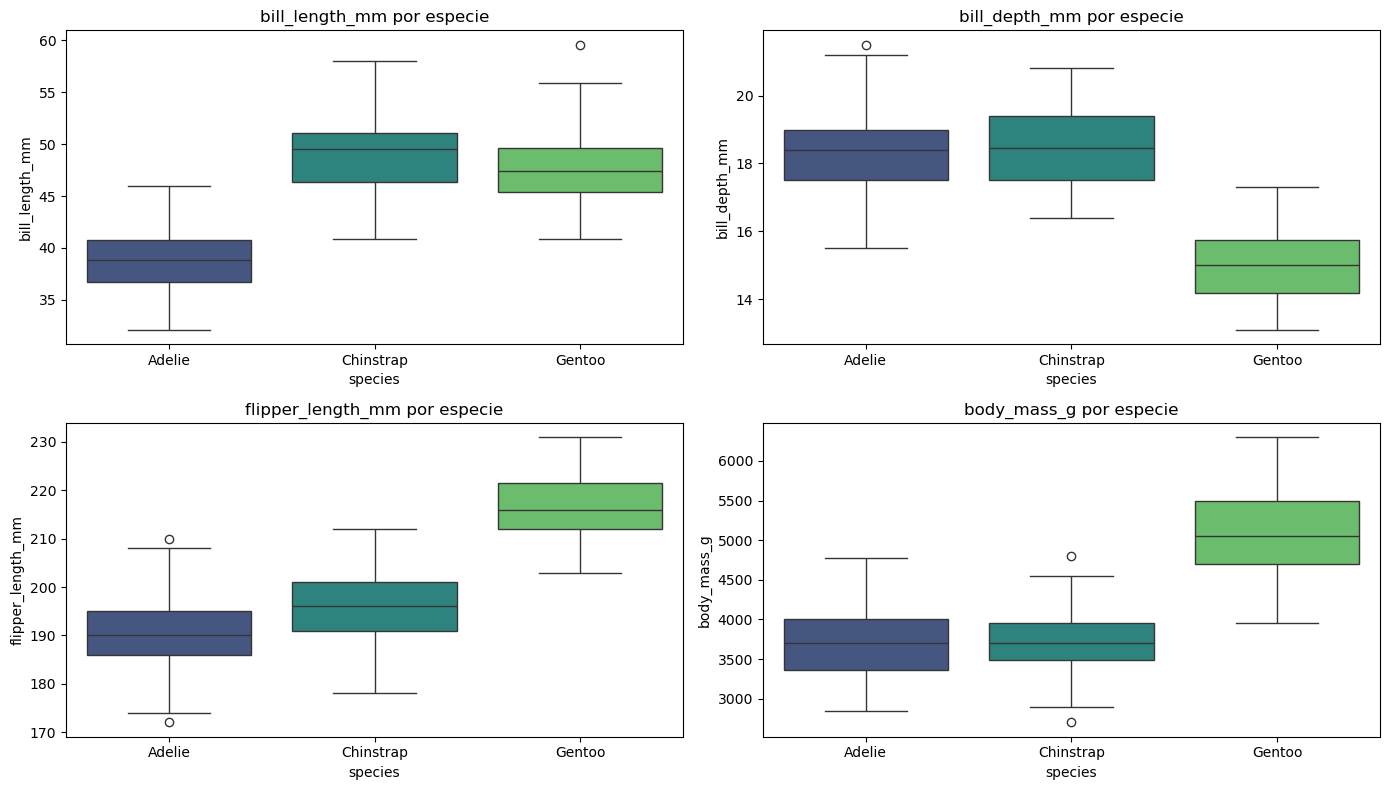

In [13]:
plt.figure(figsize=(14, 8))
for i, col in enumerate(numericas, 1):
    plt.subplot(2, 2, i)
    sns.boxplot(data=df, x='species', y=col, hue='species', palette='viridis', legend=False)
    plt.title(f'{col} por especie')
plt.tight_layout()
plt.show()

### **Conteo por variables categóricas**

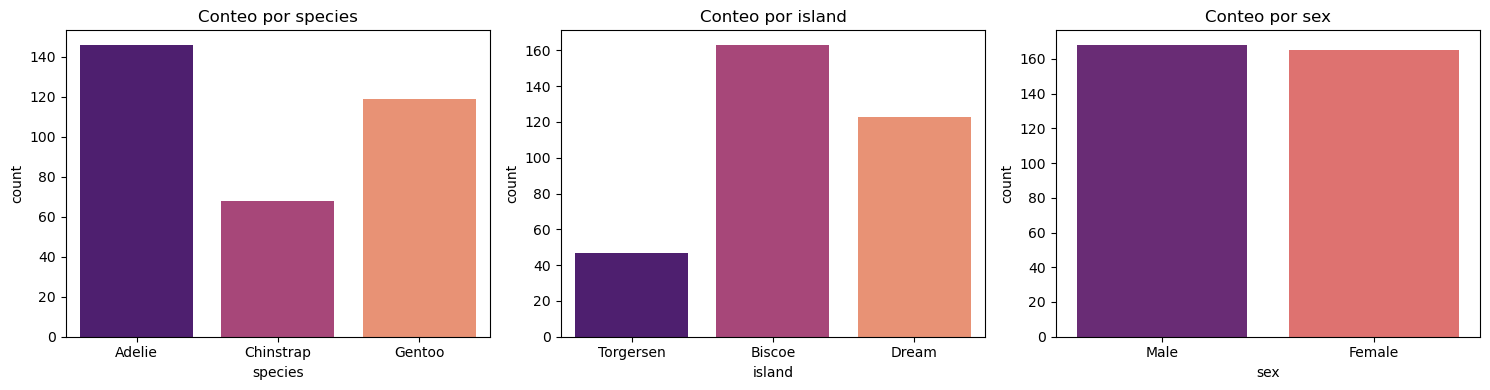

In [14]:
plt.figure(figsize=(15, 4))
for i, col in enumerate(categoricas, 1):
    plt.subplot(1, 3, i)
    sns.countplot(data=df, x=col, hue=col, palette='magma', legend=False)
    plt.title(f'Conteo por {col}')
plt.tight_layout()
plt.show()

### **Matriz de correlación**

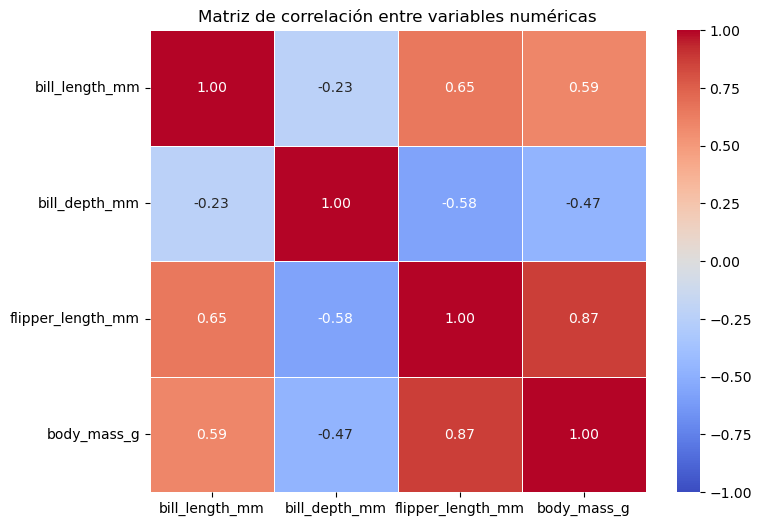

In [15]:
corr = df[numericas].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f', vmin=-1, vmax=1, linewidths=0.5)
plt.title('Matriz de correlación entre variables numéricas')
plt.show()

Se observa una correlación positiva muy fuerte (0.87) entre `flipper_length_mm` y `body_mass_g`, a mayor longitud de aleta, mayor masa corporal. Esta será la relación que modelaremos con la regresión lineal.

### **Relaciones entre variables por especie**

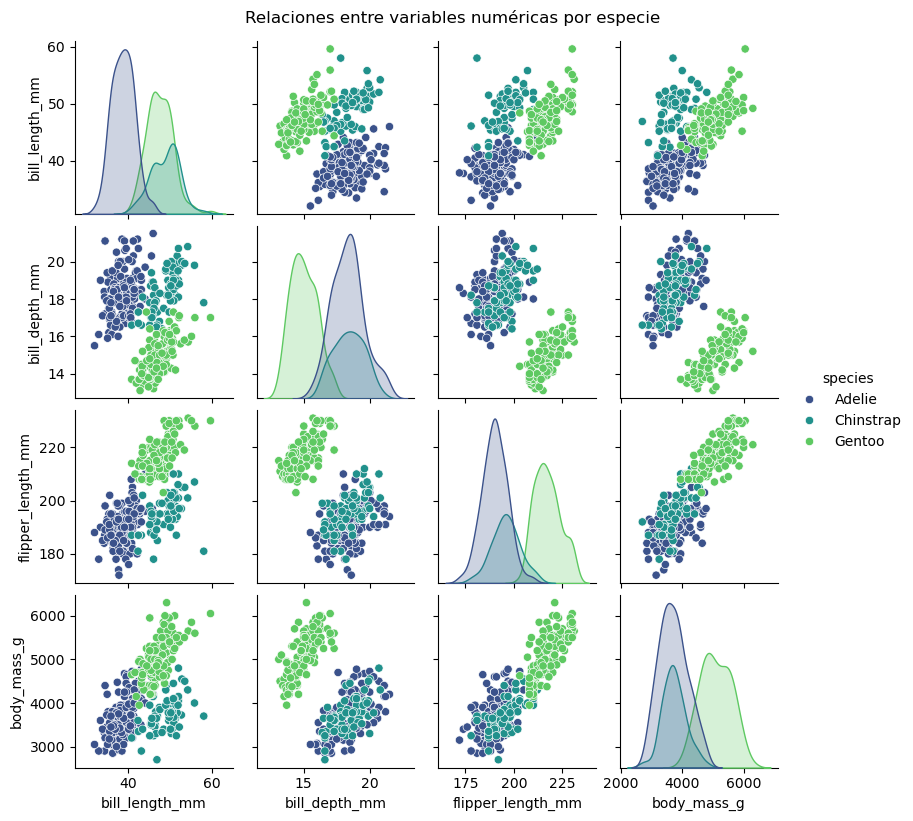

In [16]:
sns.pairplot(df, vars=numericas, hue='species', palette='viridis', height=2)
plt.suptitle('Relaciones entre variables numéricas por especie', y=1.02)
plt.show()

## **3. REGRESIÓN LINEAL SIMPLE**

Aplicaremos una **regresión lineal simple** para predecir la **masa corporal** (`body_mass_g`, variable dependiente) a partir de la **longitud de la aleta** (`flipper_length_mm`, variable independiente), por ser el par con mayor correlación lineal.

El modelo tiene la forma:

$$ y = m \cdot x + b $$

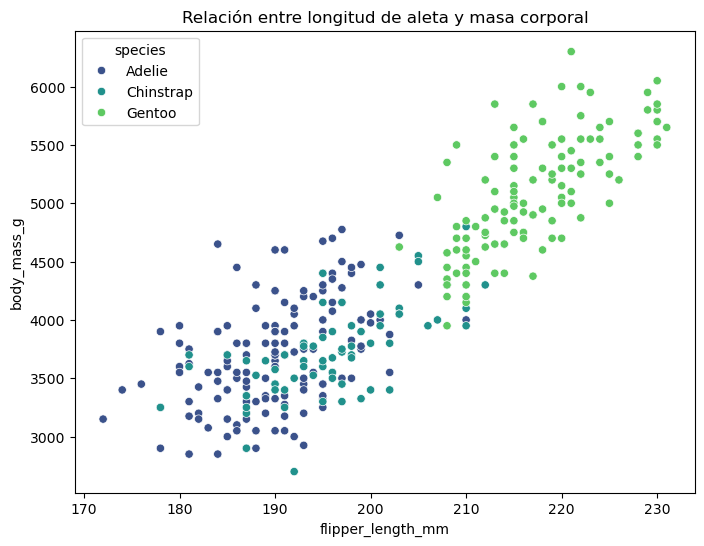

Correlación: 0.873


In [17]:
# Visualizar la relación a modelar
plt.figure(figsize=(8, 6))
sns.scatterplot(data=df, x='flipper_length_mm', y='body_mass_g', hue='species', palette='viridis')
plt.title('Relación entre longitud de aleta y masa corporal')
plt.xlabel('flipper_length_mm')
plt.ylabel('body_mass_g')
plt.show()

print('Correlación:', round(df['flipper_length_mm'].corr(df['body_mass_g']), 4))

### **Definición de las variables del modelo**

In [18]:
X = df['flipper_length_mm'].values.astype(float)  # Variable independiente
y = df['body_mass_g'].values.astype(float)        # Variable dependiente

### **Cálculo de coeficientes por mínimos cuadrados**


$$ m = \frac{\sum (x_i - \bar{x})(y_i - \bar{y})}{\sum (x_i - \bar{x})^2} \qquad b = \bar{y} - m\,\bar{x} $$

In [19]:
x_mean, y_mean = X.mean(), y.mean()

m = np.sum((X - x_mean) * (y - y_mean)) / np.sum((X - x_mean) ** 2)  # Pendiente
b = y_mean - m * x_mean                                              # Intercepto

print(f'Pendiente (m): {m:.4f}')
print(f'Intercepto (b): {b:.4f}')
print(f'Ecuación (mínimos cuadrados): body_mass_g = {m:.4f} * flipper_length_mm + ({b:.4f})')

Pendiente (m): 50.1533
Intercepto (b): -5872.0927
Ecuación (mínimos cuadrados): body_mass_g = 50.1533 * flipper_length_mm + (-5872.0927)


### **Ajuste por descenso de gradiente**

Ajuste de los coeficientes de forma iterativa minimizando el **error cuadrático medio (MSE)**. Como `flipper_length_mm` y `body_mass_g` tienen escalas muy distintas, primero se **estandarizan** las variables (z-score) para que el algoritmo converja de forma estable.

In [20]:
# Estandarización (z-score)
mx, sx = X.mean(), X.std()
my, sy = y.mean(), y.std()
X_std = (X - mx) / sx
y_std = (y - my) / sy

# Hiperparámetros
lr = 0.1        # Tasa de aprendizaje
epochs = 1000   # Número de épocas
n = len(X_std)

# Inicialización
m_std, b_std = 0.0, 0.0
perdidas = []

for epoca in range(epochs):
    y_pred = m_std * X_std + b_std
    error = y_pred - y_std
    perdidas.append(np.mean(error ** 2))      # MSE
    m_std -= lr * (2/n) * np.dot(error, X_std)
    b_std -= lr * (2/n) * np.sum(error)

# Regresar los coeficientes a la escala original
m_gd = m_std * sy / sx
b_gd = my + sy * b_std - m_gd * mx

print(f'Ecuación (descenso de gradiente): body_mass_g = {m_gd:.4f} * flipper_length_mm + ({b_gd:.4f})')

Ecuación (descenso de gradiente): body_mass_g = 50.1533 * flipper_length_mm + (-5872.0927)


### **Visualización del modelo y curva de pérdidas**

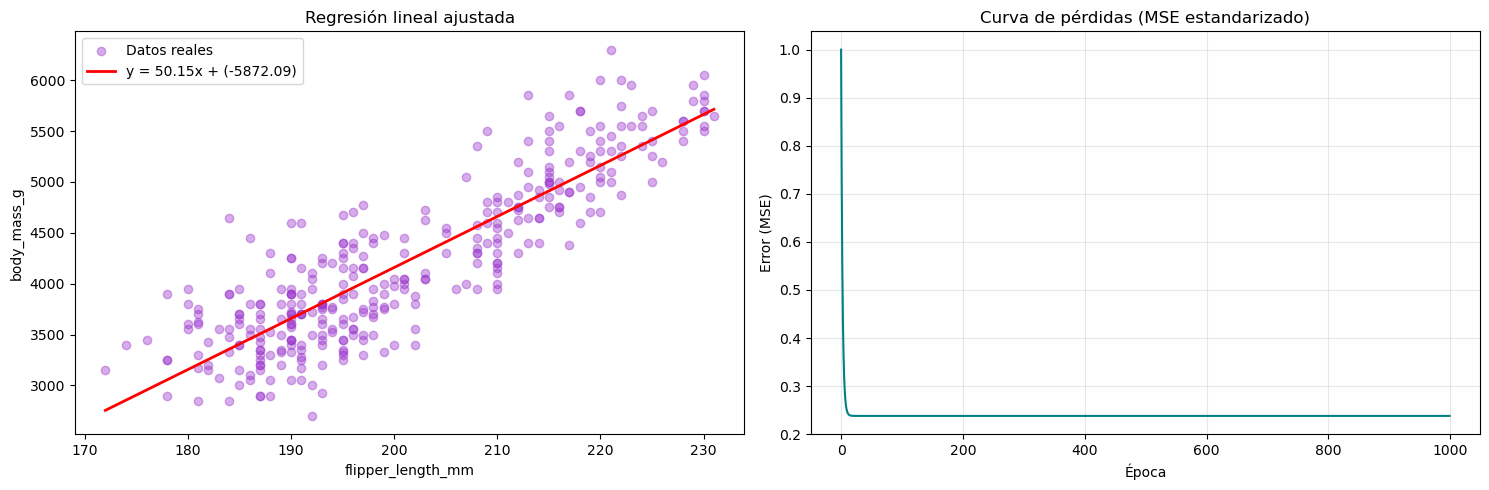

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Modelo ajustado sobre los datos reales
axes[0].scatter(X, y, alpha=0.4, color='darkorchid', label='Datos reales')
x_line = np.linspace(X.min(), X.max(), 100)
axes[0].plot(x_line, m_gd * x_line + b_gd, color='red', linewidth=2,
             label=f'y = {m_gd:.2f}x + ({b_gd:.2f})')
axes[0].set_title('Regresión lineal ajustada')
axes[0].set_xlabel('flipper_length_mm')
axes[0].set_ylabel('body_mass_g')
axes[0].legend()

# Curva de pérdidas
axes[1].plot(range(epochs), perdidas, color='teal')
axes[1].set_title('Curva de pérdidas (MSE estandarizado)')
axes[1].set_xlabel('Época')
axes[1].set_ylabel('Error (MSE)')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

### **Evaluación del modelo**

Se evalúa la calidad del ajuste con el **coeficiente de determinación (R²)** y el **error cuadrático medio (RMSE)**.

In [22]:
y_pred = m_gd * X + b_gd

ss_res = np.sum((y - y_pred) ** 2)
ss_tot = np.sum((y - y.mean()) ** 2)
r2 = 1 - ss_res / ss_tot
rmse = np.sqrt(np.mean((y - y_pred) ** 2))

print(f'Coeficiente de determinación (R²): {r2:.4f}')
print(f'Error cuadrático medio (RMSE): {rmse:.2f} g')
reduccion = round((perdidas[0] - perdidas[-1]) / perdidas[0] * 100, 2)
print(f'Reducción de la pérdida: {perdidas[0]:.4f} -> {perdidas[-1]:.4f} ({reduccion}%)')

Coeficiente de determinación (R²): 0.7621
Error cuadrático medio (RMSE): 392.16 g
Reducción de la pérdida: 1.0000 -> 0.2379 (76.21%)


In [23]:
# Predicción de ejemplo
flipper_ejemplo = 210
masa_estimada = m_gd * flipper_ejemplo + b_gd
print(f'Para una aleta de {flipper_ejemplo} mm, la masa corporal estimada es {masa_estimada:.0f} g')

Para una aleta de 210 mm, la masa corporal estimada es 4660 g


## **4. CONCLUSIONES**

* Se mostró que las varaiables numéricas presentan distribuciones diferenciadas por especie, siendo la especi Gentoo la de mayor masa corporal y longitud de aleta.
*  Se identifico una relación lineal positiva muy fuerte, entre la longitud de la aleta y la masa corporal.
* La regresión lineal simple ajustada por descenso de gradiente convergió igual que la de mínimos cuadrados. Cada milímetro se asocia con un aumento aproximado de 50g de masa corporal
* El modelo explica el 76% de la variabilidad de la masa corporal, usando solo una variable predictora
